In [1]:
#import
import sys
import os

BASE_DIR = os.getcwd()

ROOT_DIR = os.path.abspath(os.path.join(BASE_DIR, '..'))

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
    
import pandas as pd
import joblib
import warnings

warnings.filterwarnings("ignore")
from richieste.funzioni_commit import (
                                create_all_base_features,
                                create_interactions,
                                final_preprocess,
                                create_from_models,
                                plot_model_results
)

from richieste.classes import ModelPredictor
from richieste.funzioni_commit import detect_consistent_anomalies, create_final_df
def ensure_const_and_align(X, const_name="const"):
    X = X.copy()

    # 1. Aggiunta esplicita della costante se manca
    
    if const_name not in X.columns:
        X.insert(0, const_name, 1.0)
    return X

%reload_ext autoreload
%autoreload 2


In [2]:
prov = "MI".upper()

FILE_PATH   = os.path.join(ROOT_DIR, "output_province", f"traffico_{prov}.parquet")
OUTPUT_DIR  = os.path.join(BASE_DIR, "Modelli_traffico", prov)

#inserire 'count_traffico' o 'velocita_avg'
TARGET      ='count_traffico'

START_TRAIN = pd.to_datetime("2024-01-01 00:00:00")
END_TRAIN = pd.to_datetime("2024-12-31 23:00:00")

START_TEST = pd.to_datetime("2026-01-16 00:00:00")
END_TEST =  pd.to_datetime("2026-01-25 23:00:00")

os.makedirs(OUTPUT_DIR, exist_ok=True)

parq = pd.read_parquet(FILE_PATH)
#nel nostro caso, il codice catastale (belfiore) di milano marittima

print(parq['comune_amm'].unique())

['A010' 'A127' 'A375' 'A389' 'A413' 'A473' 'A618' 'A652' 'A697' 'A699'
 'A751' 'A804' 'A820' 'A872' 'A920' 'A940' 'B162' 'B235' 'B240' 'B286'
 'B292' 'B301' 'B448' 'B461' 'B593' 'B820' 'B850' 'B938' 'B989' 'C003'
 'C013' 'C014' 'C033' 'C052' 'C523' 'C536' 'C537' 'C565' 'C569' 'C707'
 'C733' 'C895' 'C908' 'C986' 'D013' 'D018' 'D033' 'D045' 'D198' 'D229'
 'D231' 'D244' 'D367' 'D845' 'D912' 'D995' 'E094' 'E170' 'E258' 'E313'
 'E317' 'E395' 'E415' 'E514' 'E610' 'E639' 'E801' 'E819' 'E921' 'F003'
 'F084' 'F100' 'F119' 'F155' 'F205' 'F783' 'F874' 'F939' 'F955' 'F968'
 'G078' 'G181' 'G206' 'G220' 'G316' 'G324' 'G385' 'G488' 'G502' 'G634'
 'G686' 'G772' 'G955' 'G965' 'H026' 'H240' 'H264' 'H371' 'H373' 'H470'
 'H560' 'H623' 'H803' 'H827' 'H884' 'H930' 'I361' 'I409' 'I415' 'I566'
 'I577' 'I602' 'I690' 'I696' 'I700' 'I786' 'L408' 'L409' 'L411' 'L415'
 'L454' 'L471' 'L664' 'L665' 'L667' 'L773' 'L883' 'L928' 'M053' 'M091'
 'M102' 'M176' 'M424']


In [3]:
com     = 'F205'.upper()
zone    = parq.groupby('comune_amm')['zona'].unique()

print(com.upper() + ' ' + str(zone.loc[com.upper()].tolist()))

F205 ['B12', 'B13', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'D10', 'D12', 'D13', 'D15', 'D16', 'D18', 'D20', 'D21', 'D24', 'D25', 'D28', 'D30', 'D31', 'D32', 'D33', 'D34', 'D35', 'D36', 'E5', 'E6', 'E7', 'E8', 'R2']


In [6]:
zona    = 'R2'
to_prep = parq[(parq['comune_amm'] == com.upper()) & (parq['zona'] == zona.upper())]

In [7]:
df          = final_preprocess(to_prep, END_TEST)
base, info  = create_all_base_features(df, k_hour=4, k_week=2)
inter, _    = create_interactions(base, info)

X_global    = pd.concat([base, inter], axis=1)
y           = df[TARGET]

Creando feature base...

✓ 31 feature base create

✓ Totale 152 interazioni create



In [8]:
X_global = X_global.copy()
X_train = X_global[df['datetime'].between(START_TRAIN, END_TRAIN)]
y_train = df[df['datetime'].between(START_TRAIN, END_TRAIN)][TARGET]
print(f"Dimensioni df TRAIN con armoniche: {X_train.shape}, dimensioni serie storica: {y_train.shape}")

X_global = X_global.copy()
X_test = X_global[df['datetime'].between(START_TEST, END_TEST)]
y_test = df[df['datetime'].between(START_TEST, END_TEST)][TARGET]
ds_test = df[df['datetime'].between(START_TEST, END_TEST)]['datetime']
print(f"Dimensioni df TRAIN con armoniche: {X_test.shape}, dimensioni serie storica: {y_test.shape}")

Dimensioni df TRAIN con armoniche: (8784, 183), dimensioni serie storica: (8784,)
Dimensioni df TRAIN con armoniche: (240, 183), dimensioni serie storica: (240,)


In [9]:
X_train_const = ensure_const_and_align(X_train)
X_test_const = ensure_const_and_align(X_test)
model_name, model = create_from_models(
                        X_train = X_train,
                        y_train = y_train,
                        model_type = 'negbin+sarimax')

my_model = ModelPredictor(model_nb = model[0],
                          model_sarima= model[1],
                          alpha = model[0].params['alpha']
                          )

nome_modello = f'{prov}_{com}_{zona}_{model_name}.pkl'

OUTPUT_PATH = os.path.join(OUTPUT_DIR, nome_modello)

joblib.dump(my_model, OUTPUT_PATH, compress=9)

print('Classe ModelPredictor salvata con successo')

print da dentro create_logiche (8784, 184)
Classe ModelPredictor salvata con successo


IL CODICE PER CREARE IL MODELLO è QUELLO SOPRA: DA QUA IN AVANTI TROVIAMO UNA IMPLEMENTAZIONE DELLA LOGICA UTILIZZANDO IL MODELLO SALVATO PER COMPIERE PREVISIONI (si noti come viene caricato un oggetto ModelPredictor in formato pickle e venga usato esclusivamente lui come modello previsionale.)

In [10]:
with open(OUTPUT_PATH, 'rb') as f:
    loaded_predictor = joblib.load(f)

# Utilizzo del metodo della classe

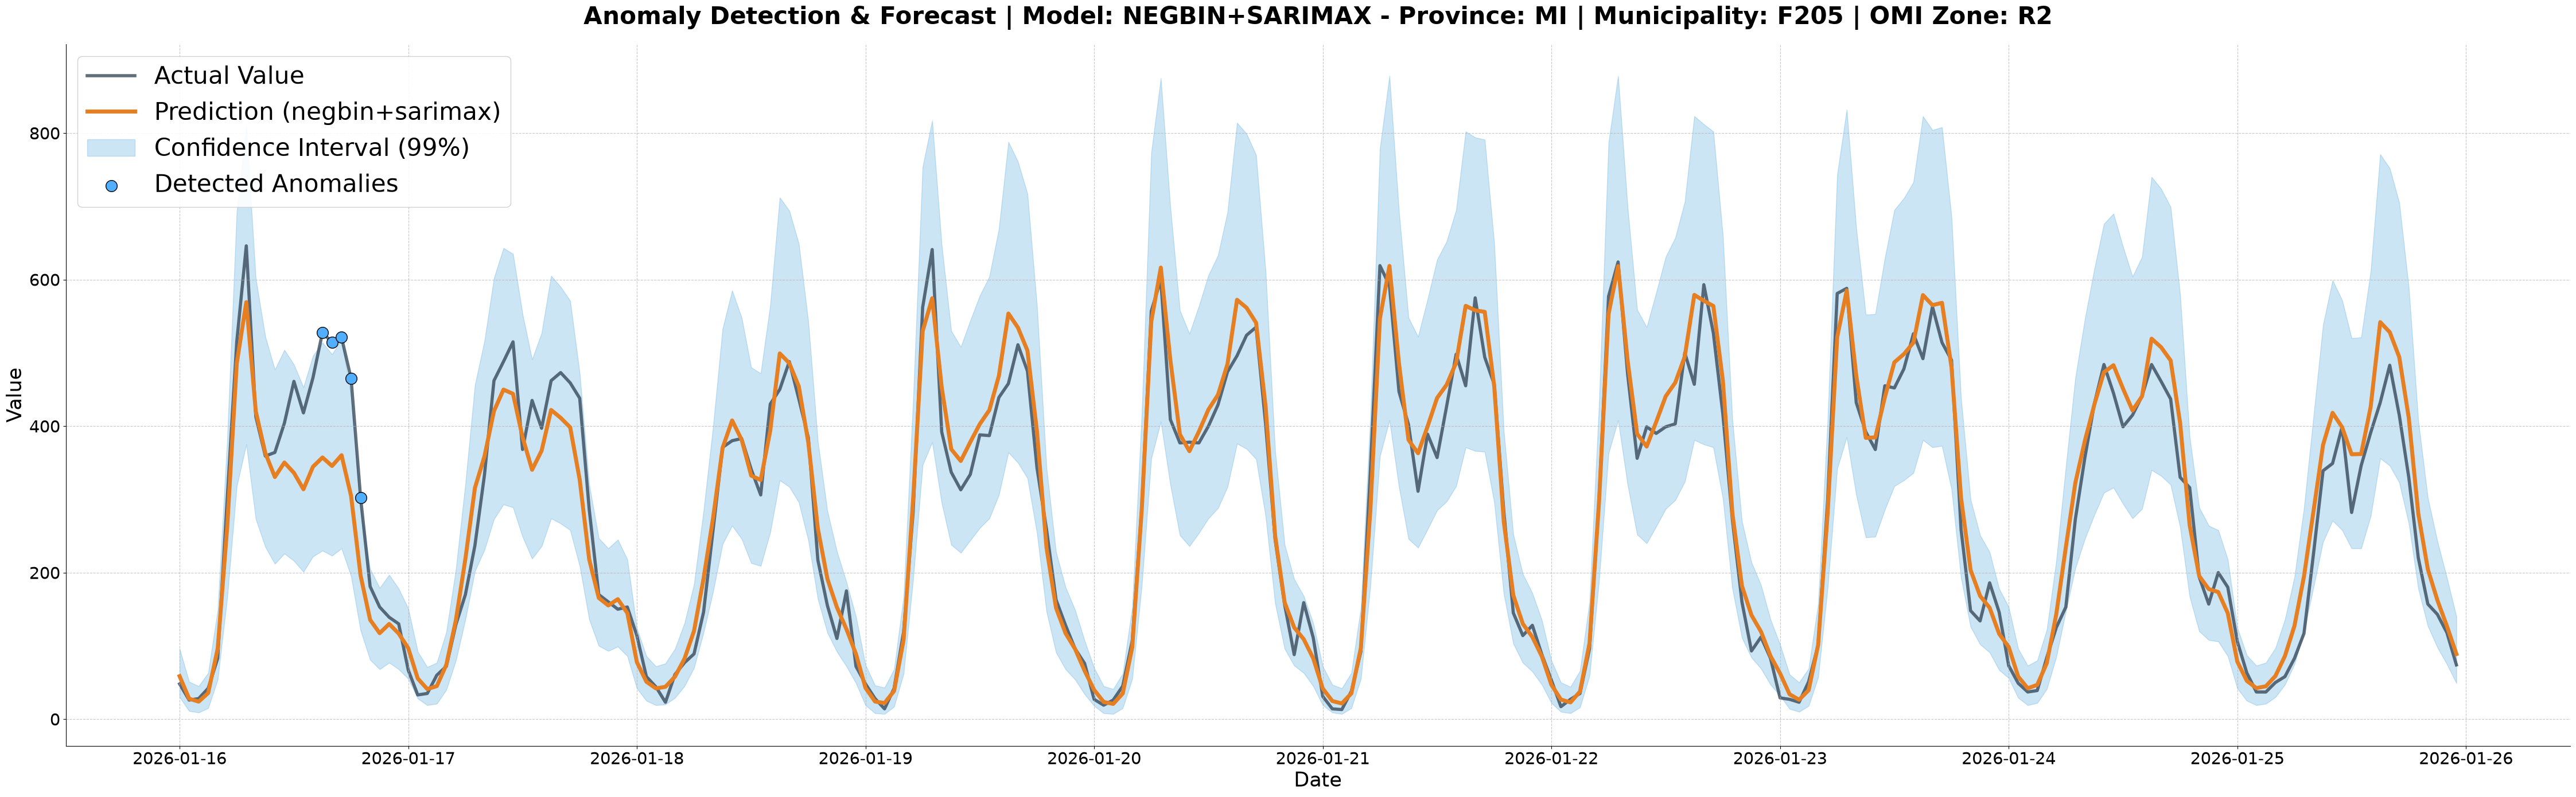

il numero assoluto di anomalie possibili è 5
il numero di anomalie possibili, in percentuale, è 2.083333333333333%

Anomalie
il numero assoluto di anomalie probabili è 0
il numero di anomalie, in percentuale, è 0.0%


,ds,y_real,lower_99,y_pred,upper_99,is_anomaly,true_anomaly
15,2026-01-16 15:00:00,528.0,230.0,357.119263,514.0,True,False
16,2026-01-16 16:00:00,514.0,223.0,345.546742,498.0,True,False
17,2026-01-16 17:00:00,521.0,233.0,360.234225,518.0,True,False
18,2026-01-16 18:00:00,465.0,195.0,304.729587,441.0,True,False
19,2026-01-16 19:00:00,302.0,121.0,195.840500,289.0,True,False


In [11]:
# Applicazione
#la funzione predict prevede anche l'estensioen del modello sarimax sui dati antecedenti al test set.
results_df = loaded_predictor.predict(X_test = X_test_const,
                                      y_test = y_test,
                                      X_global = X_global,
                                      ds_test = ds_test,
                                      df = df)
results_df = detect_consistent_anomalies(results_df, min_daily_weight=4)

results_df.set_index('ds', inplace=True)
plot_model_results(results_df, model_name, prov, com, zona)

results_df = results_df.reset_index(names = 'ds')
final_df = create_final_df(results_df)

anomalies = final_df[final_df['is_anomaly'] == True]
display(anomalies)